In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sklearn
# %matplotlib inline   <- not needed: Jupyter shows plots on its own, and this line hides them on Anaconda 2024.10

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.simplefilter("ignore", UserWarning)

In [3]:
# Fix the precision for real number print in this notebook
%precision 4

'%.4f'

In [4]:
# Load data and store it into pandas DataFrame objects
df = pd.read_csv("WineQuality.csv")
print(df.shape)
df.head()

(1809, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,8.0,0.45,0.36,8.8,0.026,50.0,151.0,0.99270,3.07,0.25,12.7,Good
1,8.3,0.21,0.41,2.2,0.050,24.0,108.0,0.99400,2.85,0.45,9.5,Poor
2,7.6,0.27,0.29,2.5,0.059,37.0,115.0,0.99328,3.09,0.37,9.8,Poor
3,6.0,0.18,0.31,1.4,0.036,14.0,75.0,0.99085,3.34,0.58,11.1,Good
4,7.0,0.14,0.28,1.3,0.026,10.0,56.0,0.99352,3.46,0.45,9.9,Poor


<Axes: xlabel='quality', ylabel='count'>

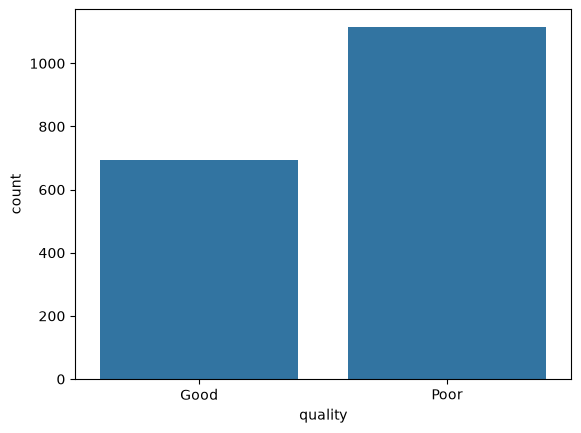

In [5]:
# Obtain the distribution of the class labels
sns.countplot(x = "quality", data = df)

In [6]:
# Define class labels
tname = "quality"

# Create a dataframe for input attributes
X = df.drop(tname, axis = 1)

# Create a dataframe for class labels
y = df[tname]

In [7]:
# Obtain attribute(feature) names (used for tree visualization)
fnames = list(X.columns)
print(fnames)

# Obtain class label names (used for tree visualization)
cnames = np.sort(y.unique())
print(cnames)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
['Good' 'Poor']


In [9]:
# Split the data into training (80%) and testing (20%). 
# Random_state is to make sure the results are consistent across different runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)